In [4]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [5]:
# Load the dataset
data = pd.read_csv('/content/hour.csv')

# Preview the dataset
print(data.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


In [25]:
data=data.copy()
data.rename(columns={
    'hr': 'hour',
    'temp': 'temperature',
    'hum': 'humidity',
    'holiday': 'is_holiday',
    'weekday': 'day_of_week',
    'mnth': 'month'
    }, inplace=True)
data['dteday'] = pd.to_datetime(data['dteday'])
data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
print(data.head())

   instant     dteday  season  yr  month  hour  is_holiday  day_of_week  \
0        1 2011-01-01       1   0      1     0           0            6   
1        2 2011-01-01       1   0      1     1           0            6   
2        3 2011-01-01       1   0      1     2           0            6   
3        4 2011-01-01       1   0      1     3           0            6   
4        5 2011-01-01       1   0      1     4           0            6   

   workingday  weathersit  temperature   atemp  humidity  windspeed  casual  \
0           0           1         0.24  0.2879      0.81        0.0       3   
1           0           1         0.22  0.2727      0.80        0.0       8   
2           0           1         0.22  0.2727      0.80        0.0       5   
3           0           1         0.24  0.2879      0.75        0.0       3   
4           0           1         0.24  0.2879      0.75        0.0       0   

   registered  cnt  is_weekend  
0          13   16           1  
1       

In [8]:
# Check for missing values
print(data.isnull().sum())

# Fill missing values (if any) with the median or remove rows (depending on your use case)
data.fillna(data.median(), inplace=True)

instant        0
dteday         0
season         0
yr             0
month          0
hour           0
is_holiday     0
day_of_week    0
workingday     0
weathersit     0
temperature    0
atemp          0
humidity       0
windspeed      0
casual         0
registered     0
cnt            0
is_weekend     0
dtype: int64


In [11]:
# Features (independent variables)
X = data[['hour', 'temperature', 'humidity', 'windspeed', 'is_holiday', 'day_of_week', 'month', 'is_weekend']]

# Target variable (dependent variable)
y = data['cnt']

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the split size
print(f'Training data size: {X_train.shape[0]}')
print(f'Testing data size: {X_test.shape[0]}')

Training data size: 13903
Testing data size: 3476


In [13]:
# Initialize the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Model training is complete
print("Model training completed!")

Model training completed!


In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Print the MAE
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 44.04184457367527


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score # Import r2_score

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)
print("Random Forest R2:", r2_rf)

Random Forest R2: 0.8539587403727112


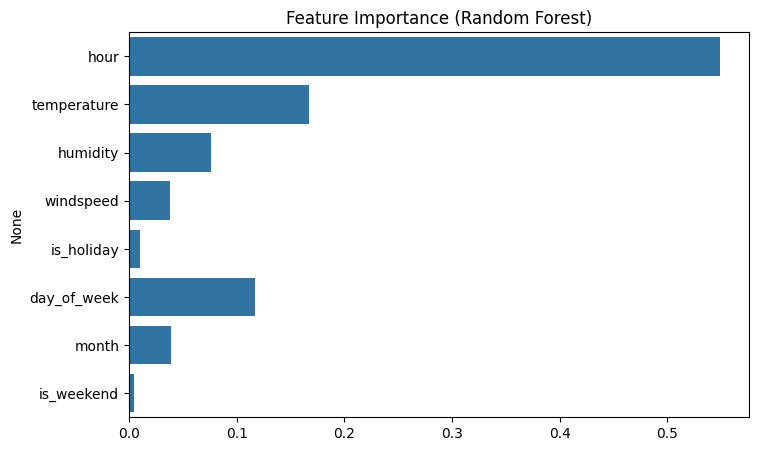

In [18]:
import seaborn as sns

importance = model.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=X.columns)
plt.title("Feature Importance (Random Forest)")
plt.show()

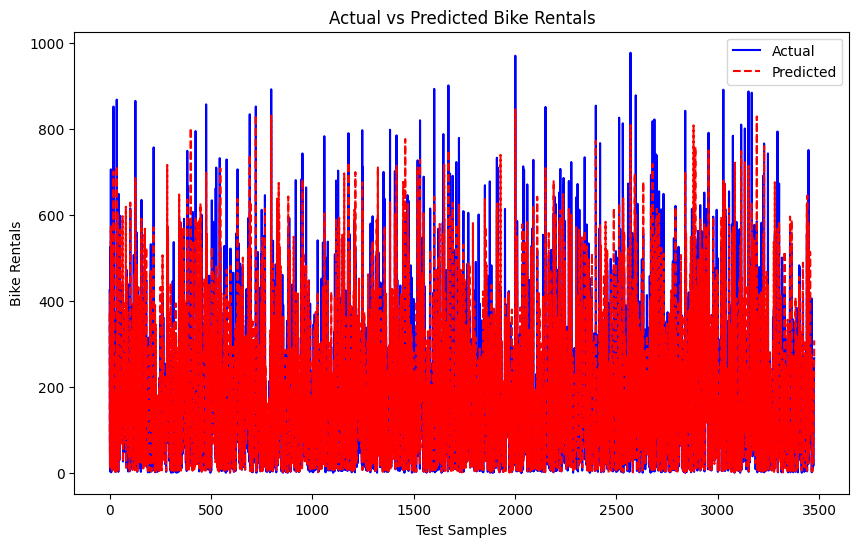

In [15]:
# Plot the actual vs predicted bike rentals
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Bike Rentals')
plt.xlabel('Test Samples')
plt.ylabel('Bike Rentals')
plt.legend()
plt.show()

In [16]:
# New input for prediction (For example: 3 PM, sunny, 25°C temperature, 5 m/s wind speed)
new_data = pd.DataFrame({
    'hour': [15],
    'temperature': [25],
    'humidity': [60],  # Assuming average humidity
    'windspeed': [5],
    'is_holiday': [0],  # Assume it's not a holiday
    'day_of_week': [2],  # Assume it's a Tuesday
    'month': [5],  # Assuming May
    'is_weekend': [0]  # Not a weekend
})

# Make the prediction
bike_prediction = model.predict(new_data)
print(f'Predicted number of bikes rented: {bike_prediction[0]}')

Predicted number of bikes rented: 103.25
